In [1]:
import os
os.chdir('../')

In [2]:
import torch
from pathlib import Path

def load_feats(d, k="inception_feature"):
    xs=[]
    for p in Path(d).rglob("*.pt"):
        v = torch.load(p, map_location="cpu")
        v = v[k] if isinstance(v, dict) else v
        xs.append(v.view(-1, 2048).float())
    return torch.cat(xs, 0)  # (B, 2048)

@torch.no_grad()
def precision_recall_torch(ref_features, sample_features, k=3, normalize=False, radius_scale=1.0):
    assert ref_features.dim()==2 and sample_features.dim()==2
    assert ref_features.size(1)==sample_features.size(1)
    R, G = ref_features, sample_features
    if normalize:
        R = torch.nn.functional.normalize(R, dim=1)
        G = torch.nn.functional.normalize(G, dim=1)

    def knn_radii(X, k):
        n = X.size(0); k = max(1, min(k, n-1))
        D = torch.cdist(X, X); D.fill_diagonal_(float('inf'))
        return D.kthvalue(k, dim=1).values

    r = knn_radii(R, k) * radius_scale   # 실측 매니폴드 반경
    s = knn_radii(G, k) * radius_scale   # 생성 매니폴드 반경
    D = torch.cdist(R, G)
    precision = (D <= r[:, None]).any(0).float().mean().item()
    recall    = (D <= s[None, :]).any(1).float().mean().item()
    return precision, recall


In [3]:
valid_features = torch.load('/dataset/dit/valid_feats.pt')['features']
valid_features.shape

torch.Size([10000, 2048])

100%|██████████| 20/20 [02:18<00:00,  6.91s/it]


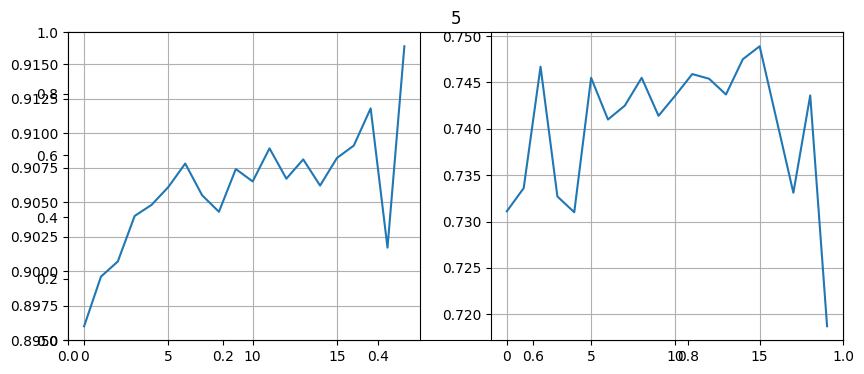

In [4]:
from tqdm import tqdm
import matplotlib.pyplot as plt

precisions = {}
recalls = {}
k = 5
NFE = 9
precisions[k] = []
recalls[k] = []
for i in tqdm(range(0, 20)):
    dir = f"samplings/GMDiT/1.4/{NFE}/Dual-Solver/10000/which_{i}/"
    if not os.path.exists(dir):
        continue
        
    sample_features = load_feats(dir)
    #print('sample_features')
    precision, recall = precision_recall_torch(valid_features, sample_features, k=k)
    #print('precision, recall')
    precisions[k].append(precision)
    recalls[k].append(recall)

plt.figure(figsize=[10, 4])
plt.title(f"{k}")
plt.subplot(1, 2, 1)
plt.grid()
plt.plot(precisions[k])
plt.subplot(1, 2, 2)
plt.plot(recalls[k])
plt.grid()
plt.show()
    

In [6]:
recalls

{5: [0.7311000227928162,
  0.7336000204086304,
  0.7466999888420105,
  0.732699990272522,
  0.7310000061988831,
  0.7455000281333923,
  0.7409999966621399,
  0.7425000071525574,
  0.7455000281333923,
  0.7414000034332275,
  0.7436000108718872,
  0.7458999752998352,
  0.7454000115394592,
  0.7437000274658203,
  0.7475000023841858,
  0.7488999962806702,
  0.7409999966621399,
  0.7330999970436096,
  0.7436000108718872,
  0.7186999917030334]}